In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno

from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
import re


import matplotlib.pyplot as plt
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

<p>
<h2>주성분 분석(Principal Component Analysis, PCA)</h2>
주성분 분석(PCA)은 머신러닝에서 널리 사용되는 기법 중 하나로, 데이터의 차원을 축소하고 중요한 정보를 추출하는 데 활용<br>
복잡한 데이터셋을 간소화하면서도 주요한 특징을 유지하는 데에 도움을 줌<br><br>
데이터의 차원을 축소하여 중요한 정보를 유지하는 방법<br>
고차원 데이터를 시각화하거나, 노이즈를 줄이고, 계산 성능 개선 가능<br>
데이터에서 가장 중요한 특성(주성분)을 찾아내어 데이터의 분산을 최대화하는 방향으로 차원을 축소하는 기법

<br><br>
<h4>주성분 분석의 주요 개념</h4>

&gt; 주성분(Principal Components)<br>
     데이터의 분산이 가장 큰 방향으로 정의되는 새로운 변수<br>
     첫 번째 주성분은 데이터에서 가장 큰 분산을 가짐<br>
     두 번째 주성분은 두번째로 큰 분산을 가짐<br>
     <br>
&gt; 차원 축소<br>
    고차원 데이터에서 중요한 정보만을 추출하여 차원을 축소<br>
    원래의 데이터에 비해 더 적은 수의 차원으로 변환되지만, 가능한 한 원래 데이터의 분산을 최대한 보존<br>
    <br>
&gt; 데이터 변환<br>
    PCA는 원본 데이터를 새로운 주성분에 맞게 변환<br>
    이렇게 변환된 데이터를 사용하면, 데이터의 복잡성이 줄어들고, 시각화나 모델링이 더 쉬워질 수 있음<br>


</p>

In [2]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

In [3]:
# 아이리스 데이터셋 로드
iris = load_iris()

In [4]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
x = iris.data
y = iris.target

In [8]:
# PCA 적용 (2차원으로 축소)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

print(f"주성분들의 분산 비율: {pca.explained_variance_ratio_}")
print(f"누적 분산 비율: {np.cumsum(pca.explained_variance_ratio_)}")

주성분들의 분산 비율: [0.92461872 0.05306648]
누적 분산 비율: [0.92461872 0.97768521]


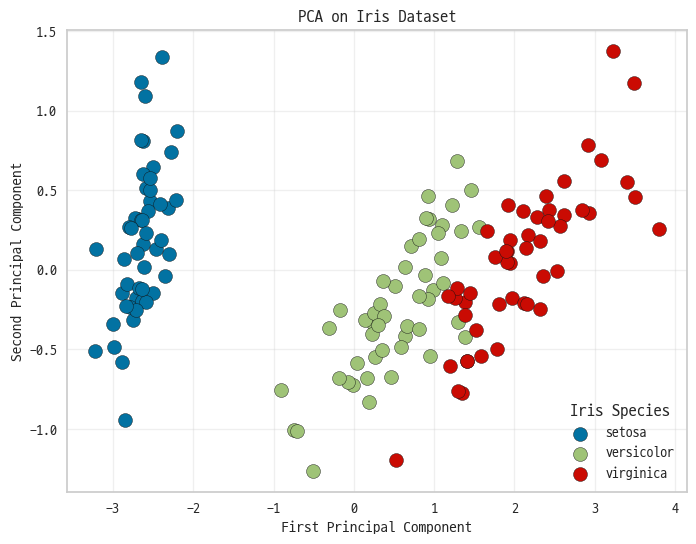

In [9]:
# 시각화
plt.figure(figsize=(8, 6))

for i, name in enumerate(iris.target_names):
    plt.scatter(
        x_pca[y == i, 0],
        x_pca[y == i, 1],
        label=name,
        s=100,
        edgecolor='k'
    )

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA on Iris Dataset')
plt.legend(title="Iris Species")
plt.grid(alpha=0.3)
plt.show()

주성분 행렬 (각 주성분의 특성 기여도):
주성분 1:
  특성 1 (sepal length (cm)): 0.3614
  특성 2 (sepal width (cm)): -0.0845
  특성 3 (petal length (cm)): 0.8567
  특성 4 (petal width (cm)): 0.3583
  -> 설명된 분산 비율: 0.9246

주성분 2:
  특성 1 (sepal length (cm)): 0.6566
  특성 2 (sepal width (cm)): 0.7302
  특성 3 (petal length (cm)): -0.1734
  특성 4 (petal width (cm)): -0.0755
  -> 설명된 분산 비율: 0.0531



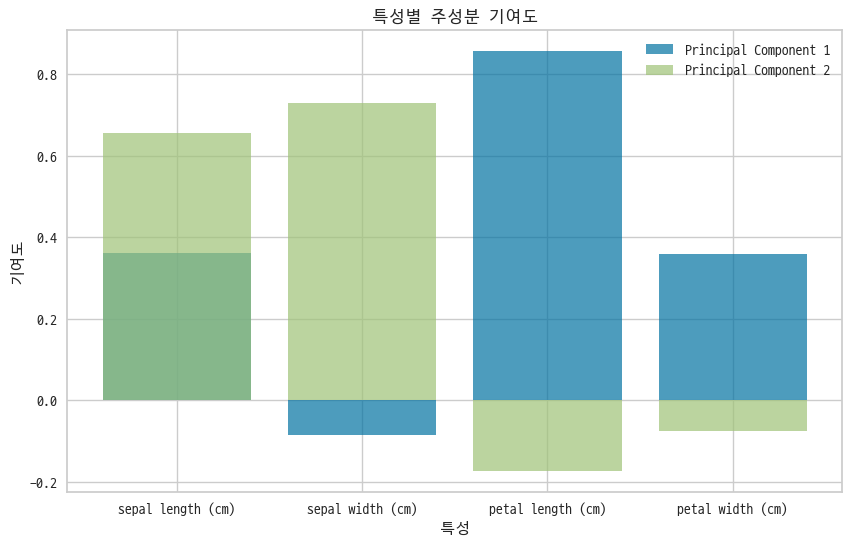

In [10]:
# 주성분과 분산 비율 정보 가져오기
components = pca.components_  # 주성분 행렬
explained_variance = pca.explained_variance_ratio_  # 분산 비율
feature_names = iris.feature_names  # 특성 이름

# 주성분의 기여도 출력
print("주성분 행렬 (각 주성분의 특성 기여도):")
for i, component in enumerate(components):
    print(f"주성분 {i + 1}:")
    for j, contribution in enumerate(component):
        print(f"  특성 {j + 1} ({feature_names[j]}): {contribution:.4f}")
    print(f"  -> 설명된 분산 비율: {explained_variance[i]:.4f}")
    print()

plt.figure(figsize=(10, 6))

# 첫 번째 주성분
plt.bar(iris.feature_names, components[0], alpha=0.7, label="Principal Component 1")

# 두 번째 주성분
plt.bar(iris.feature_names, components[1], alpha=0.7, label="Principal Component 2")

plt.title("특성별 주성분 기여도")
plt.xlabel("특성")
plt.ylabel("기여도")
plt.legend()
plt.show()

In [11]:
## 주성분행렬 결과를 판다스 DataFrame으로 
components = pca.components_  # 주성분 행렬
feature_names = iris.feature_names  # 특성 이름

pc_columns= [f'PC{i+1}' for i in range(components.shape[0])]
components_df = pd.DataFrame(components,columns=feature_names,index=pc_columns)

components_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
PC1,0.361387,-0.084523,0.856671,0.358289
PC2,0.656589,0.730161,-0.173373,-0.075481
